**Dataset Title**

USGS Earthquake Catalog – Past 30 Days (CSV Format)

Source

United States Geological Survey (USGS) – Earthquake Hazards Program
**Official dataset URL:**
➡️ https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php

Dataset Description

This dataset contains global earthquake event records for the past 30 days, published by the USGS Earthquake Hazards Program. It provides detailed seismological information for each event, including location, time, depth, and magnitude. The data is available in CSV format, making it suitable for data analysis, visualization, and integration into machine learning and optimization pipelines.

Purpose

The dataset is widely used for:

Monitoring recent earthquake activity globally

Analyzing seismic trends and event distributions

Performing hazard assessment and risk modeling

Deriving features for predictive models

This dataset is used in this project to:

Identify recent earthquake events.

Compute hazard severity scores based on earthquake characteristics.

Derive operational impact metrics (e.g., expected casualties, rescue tasks) using data-driven estimation logic.

Feed into the subsequent optimization model for resource allocation.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [ ]:
df = pd.read_csv("")

FileNotFoundError: [Errno 2] No such file or directory: '../data/usgs_earthquakes.csv'

In [19]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-26T11:23:26.196Z,62.086000,-148.840000,34.40,1.90,ml,19.0,63.0,0.300000,0.60,...,2025-12-26T11:25:06.336Z,"34 km N of Sutton-Alpine, Alaska",earthquake,0.00,4.2198,0.200000,4.0,automatic,ak,ak
1,2025-12-26T11:13:21.700Z,33.743833,-115.921167,6.87,1.33,ml,46.0,58.0,0.077950,0.18,...,2025-12-26T11:23:56.570Z,"23 km ENE of Thermal, CA",earthquake,0.19,0.5200,0.184840,27.0,automatic,ci,ci
2,2025-12-26T11:04:14.930Z,33.891500,-116.888000,12.92,1.16,ml,61.0,29.0,0.082570,0.15,...,2025-12-26T11:14:52.670Z,"4 km SSW of Banning, CA",earthquake,0.14,0.3700,0.246928,27.0,automatic,ci,ci
3,2025-12-26T11:00:18.670Z,38.796501,-122.780830,3.39,0.72,md,12.0,73.0,0.006456,0.02,...,2025-12-26T11:01:52.192Z,"3 km NW of The Geysers, CA",earthquake,0.48,0.9300,0.110000,13.0,automatic,nc,nc
4,2025-12-26T10:34:35.321Z,58.291000,-154.793000,11.50,1.70,ml,22.0,99.0,0.100000,0.40,...,2025-12-26T10:36:00.095Z,"82 km NNW of Karluk, Alaska",earthquake,0.00,2.3729,0.400000,7.0,automatic,ak,ak


In [20]:
df.shape

(9547, 22)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9547 entries, 0 to 9546
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             9547 non-null   object 
 1   latitude         9547 non-null   float64
 2   longitude        9547 non-null   float64
 3   depth            9547 non-null   float64
 4   mag              9547 non-null   float64
 5   magType          9547 non-null   object 
 6   nst              9546 non-null   float64
 7   gap              9546 non-null   float64
 8   dmin             9540 non-null   float64
 9   rms              9546 non-null   float64
 10  net              9547 non-null   object 
 11  id               9547 non-null   object 
 12  updated          9547 non-null   object 
 13  place            9547 non-null   object 
 14  type             9547 non-null   object 
 15  horizontalError  9328 non-null   float64
 16  depthError       9411 non-null   float64
 17  magError      

In [22]:
df.isnull().sum()

time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                  1
gap                  1
dmin                 7
rms                  1
net                  0
id                   0
updated              0
place                0
type                 0
horizontalError    219
depthError         136
magError            32
magNst               1
status               0
locationSource       0
magSource            0
dtype: int64

In [23]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,9547.000000,9547.000000,9547.000000,9547.000000,9546.000000,9546.000000,9540.000000,9546.000000,9328.000000,9411.000000,9515.000000,9546.000000
mean,41.185762,-113.497587,19.107369,1.753772,26.379531,101.255629,0.464180,0.375608,1.305888,2.456701,0.196765,19.095956
std,18.432734,63.099166,51.916379,1.249207,22.710024,57.899106,1.579723,0.398994,2.809532,4.553926,0.125654,28.119837
min,-63.894300,-179.955600,-3.260000,-1.310000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.686667,-140.077750,2.850000,0.900000,12.000000,59.000000,0.022350,0.100000,0.150000,0.530000,0.105982,6.000000
50%,38.821335,-122.781334,6.700000,1.600000,20.000000,86.000000,0.087350,0.190000,0.310000,1.040000,0.181381,12.000000
75%,60.022833,-116.434000,12.060000,2.300000,33.000000,127.000000,0.409730,0.620000,0.760000,2.600350,0.248000,21.000000
max,72.137700,179.993000,645.536000,7.600000,310.000000,353.000000,32.639000,5.178955,38.170000,115.885376,1.402819,754.000000


**Handling Null Values**

CORE columns (already clean – GOOD)

time

latitude

longitude

depth

mag

place

In [24]:
null_cols = ["nst", "gap", "dmin", "rms",
    "horizontalError", "depthError",
    "magError", "magNst"]

In [25]:
for col in null_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

C:\Users\default.LAPTOP-ISA0RPLA\AppData\Local\Temp\ipykernel_32920\4028134363.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
C:\Users\default.LAPTOP-ISA0RPLA\AppData\Local\Temp\ipykernel_32920\4028134363.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [26]:
df[null_cols].isnull().sum()

nst                0
gap                0
dmin               0
rms                0
horizontalError    0
depthError         0
magError           0
magNst             0
dtype: int64

In [27]:
df.isnull().sum()

time               0
latitude           0
longitude          0
depth              0
mag                0
magType            0
nst                0
gap                0
dmin               0
rms                0
net                0
id                 0
updated            0
place              0
type               0
horizontalError    0
depthError         0
magError           0
magNst             0
status             0
locationSource     0
magSource          0
dtype: int64

In [28]:
df = df.dropna(subset=["mag", "latitude", "longitude", "depth"])

**Convert Time Column**

In [29]:
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["hour"] = df["time"].dt.hour

**Exploratory Data Analysis (EDA)**

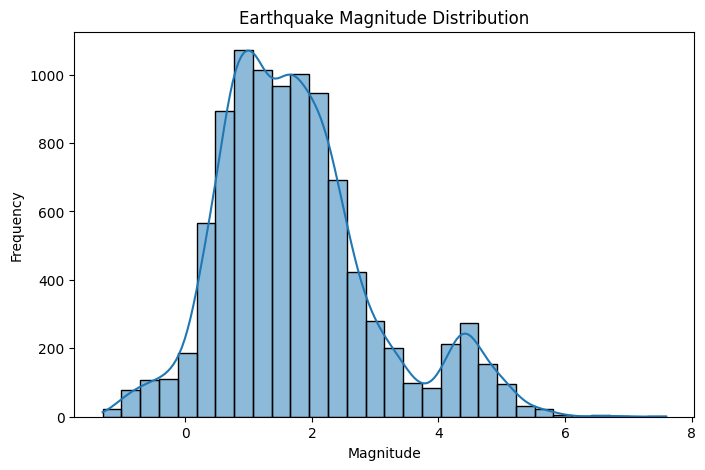

In [30]:
# Magnitude Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["mag"], bins=30, kde=True)
plt.title("Earthquake Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

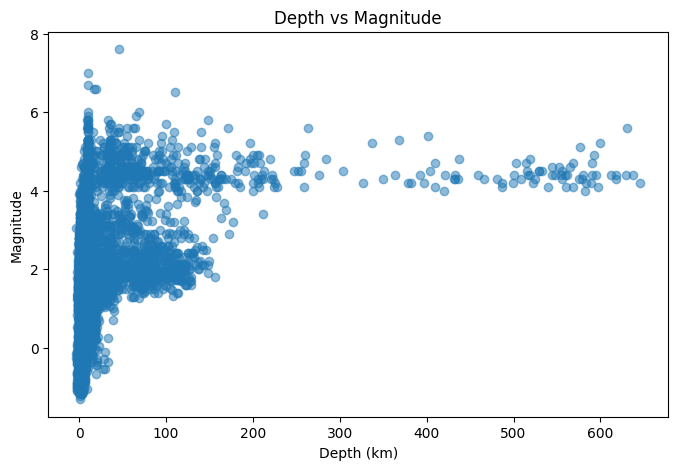

In [31]:
# Depth vs Magnitude
plt.figure(figsize=(8,5))
plt.scatter(df["depth"], df["mag"], alpha=0.5)
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.title("Depth vs Magnitude")
plt.show()

In [32]:
# Extract Region Information
df["region"] = df["place"].str.split(",").str[-1].str.strip()
df["region"].fillna("Unknown", inplace=True)

C:\Users\default.LAPTOP-ISA0RPLA\AppData\Local\Temp\ipykernel_32920\4199642827.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["region"].fillna("Unknown", inplace=True)


In [33]:
df["region"].value_counts().head()

region
CA            3458
Alaska        3212
Texas          507
Hawaii         333
New Mexico     228
Name: count, dtype: int64

In [34]:
# Hazard Severity Scoring
# This converts raw earthquake data - hazard intelligence
def hazard_score(mag):
    if mag >= 6.5:
        return 1.0
    elif mag >= 5.5:
        return 0.8
    elif mag >= 4.5:
        return 0.6
    else:
        return 0.3


In [35]:
df["hazard_score"] = df["mag"].apply(hazard_score)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9547 entries, 0 to 9546
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             9547 non-null   datetime64[ns, UTC]
 1   latitude         9547 non-null   float64            
 2   longitude        9547 non-null   float64            
 3   depth            9547 non-null   float64            
 4   mag              9547 non-null   float64            
 5   magType          9547 non-null   object             
 6   nst              9547 non-null   float64            
 7   gap              9547 non-null   float64            
 8   dmin             9547 non-null   float64            
 9   rms              9547 non-null   float64            
 10  net              9547 non-null   object             
 11  id               9547 non-null   object             
 12  updated          9547 non-null   object             
 13  place            9

In [37]:
# Priority Index Calculation
df["priority_index"] = (df["hazard_score"] * (df["mag"] / df["mag"].max())).round(2)


In [38]:
# Estimate Impact & Demand
df["expected_casualties"] = (df["priority_index"] * 2000).astype(int)
df["minor_injuries"] = (df["expected_casualties"] * 0.55).astype(int)
df["severe_injuries"] = (df["expected_casualties"] * 0.25).astype(int)
df["search_rescue_tasks"] = (df["expected_casualties"] * 0.35).astype(int)
df["first_aid_requests"] = (df["expected_casualties"] * 0.70).astype(int)


In [39]:
# Aggregate Region-wise Demand
regional_demand = df.groupby("region").agg({
    "expected_casualties": "sum",
    "minor_injuries": "sum",
    "severe_injuries": "sum",
    "search_rescue_tasks": "sum",
    "first_aid_requests": "sum",
    "priority_index": "mean"}).reset_index()


In [40]:
regional_demand.head()

,region,expected_casualties,minor_injuries,severe_injuries,search_rescue_tasks,first_aid_requests,priority_index
0,2025 Hubbard Glacier Earthquake,1840,1012,460,644,1288,0.920000
1,Afghanistan,2540,1397,635,884,1773,0.211667
2,Alabama,160,88,40,56,112,0.080000
3,Alaska,487440,268092,121860,170029,340633,0.075878
4,Argentina,7780,4279,1945,2714,5437,0.243125


In [41]:
# lean & Standardize Region Names
def extract_region(place):
    if "," in place:
        return place.split(",")[-1].strip()
    else:
        return "Unknown"

df["region"] = df["place"].apply(extract_region)

In [42]:
# Remove Non-Geographic Regions
df = df[~df["region"].str.contains("Earthquake", case=False, na=False)]

In [43]:
df = df[df["region"] != "Unknown"]

In [44]:
# Recreate Regional Demand
regional_demand = df.groupby("region").agg({
    "expected_casualties": "sum",
    "minor_injuries": "sum",
    "severe_injuries": "sum",
    "search_rescue_tasks": "sum",
    "first_aid_requests": "sum",
    "priority_index": "mean"}).reset_index() 


In [45]:
regional_demand["region"].unique()[:15]

array(['Afghanistan', 'Alabama', 'Alaska', 'Argentina', 'Arizona',
       'Arkansas', 'Australia', 'Azerbaijan', 'Bangladesh', 'Bolivia',
       'Burma (Myanmar)', 'CA', 'California', 'Canada', 'Chile'],
      dtype=object)

In [46]:
regional_demand.shape

(94, 7)

In [47]:
regional_demand.sort_values("priority_index", ascending=False).head()

,region,expected_casualties,minor_injuries,severe_injuries,search_rescue_tasks,first_aid_requests,priority_index
30,Guam,3500,1925,875,1224,2449,0.437500
7,Azerbaijan,800,440,200,280,560,0.400000
33,Iceland,780,429,195,273,546,0.390000
52,New Caledonia,1560,858,390,546,1092,0.390000
89,Vanuatu,9220,5071,2305,3225,6452,0.384167


In [48]:
df.to_csv("../outputs/hazard_scores_cleaned.csv", index=False)
regional_demand.to_csv("../outputs/regional_demand_cleaned.csv", index=False)


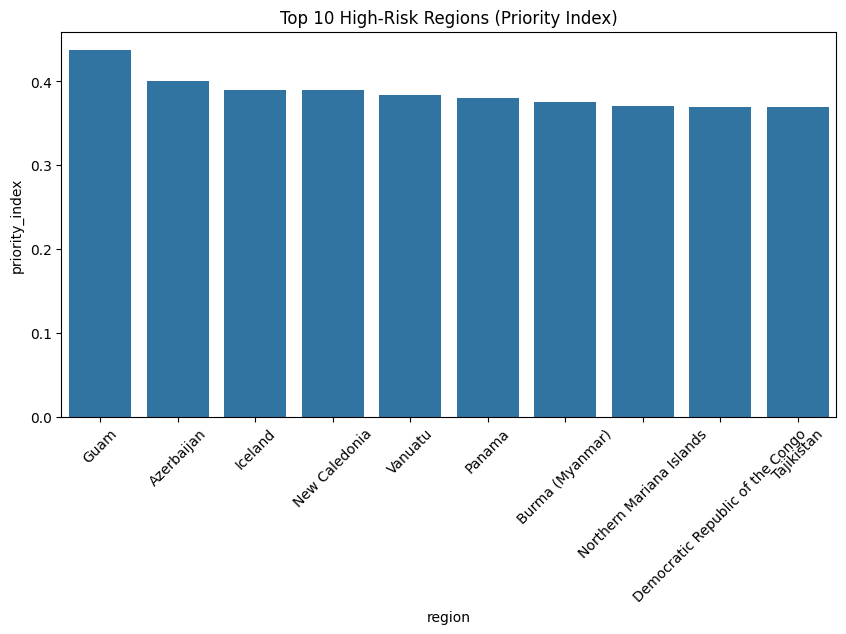

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=regional_demand.sort_values("priority_index", ascending=False).head(10),
    x="region",
    y="priority_index"
)
plt.xticks(rotation=45)
plt.title("Top 10 High-Risk Regions (Priority Index)")
plt.show()


**Outlier Analysis**

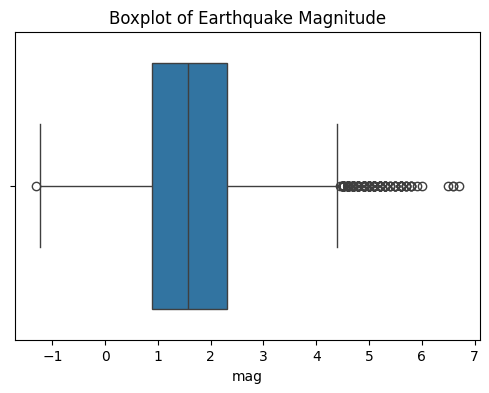

In [50]:
# Visualize Outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["mag"])
plt.title("Boxplot of Earthquake Magnitude")
plt.show()

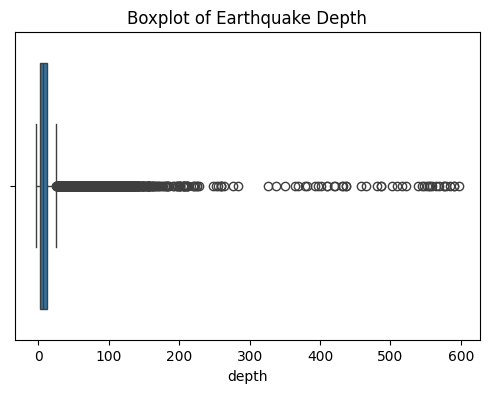

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["depth"])
plt.title("Boxplot of Earthquake Depth")
plt.show()


Although outliers were detected using boxplots, they represent genuine high-impact seismic events. Therefore, no outlier removal was performed, and robust scaling was used to mitigate their influence while preserving critical risk information.

**Feature Preparation for Modeling**

In [54]:
features = ["mag", "depth", "gap", "rms", "dmin"]
X = df[features]


In [56]:
! pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------- -------------------------- 2.6/8.0 MB 14.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 15.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/38.5 MB 23.2 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/38.5 MB 23.3 MB/s eta 0:00:02
   --------------- ------------------------ 14.7/38.5 MB 22.7 MB/s eta 0:00:02
   ----------------- ---------------------- 16.8/38.5 MB 19.7 MB/s eta 0:00:02
   ---------------------- ----------------- 22.0/38.5 MB 20.5 MB/s eta 0:00:01
   ---------------------------- ----------- 27.3/38.5 MB 21.0 MB/s eta 0:00:01
   ---------------------------------- ----- 33.3/38.5 MB 22.1 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.head()

,mag,depth,gap,rms,dmin
0,0.232394,3.029238,-0.323529,0.82,0.569871
1,-0.169014,0.033591,-0.397059,-0.02,-0.016477
2,-0.288732,0.691915,-0.823529,-0.08,-0.004278
3,-0.598592,-0.345082,-0.176471,-0.34,-0.205265
4,0.091549,0.537399,0.205882,0.42,0.041748


In [58]:
df_scaled = df.copy()
df_scaled[features] = X_scaled 

In [59]:
feature_cols = [
    "mag",
    "depth",
    "gap",
    "rms",
    "dmin"
]

X = df_scaled[feature_cols]

In [63]:
df["mag"].describe()

count    9405.000000
mean        1.708151
std         1.200046
min        -1.310000
25%         0.880000
50%         1.570000
75%         2.300000
max         6.700000
Name: mag, dtype: float64

In [64]:
q1 = df["mag"].quantile(0.70)
q2 = df["mag"].quantile(0.90)

def hazard_label_quantile(mag):
    if mag >= q2:
        return 2   # High hazard
    elif mag >= q1:
        return 1   # Medium hazard
    else:
        return 0   # Low hazard


In [65]:
df_scaled["hazard_level"] = df["mag"].apply(hazard_label_quantile)
y = df_scaled["hazard_level"]


In [66]:
y.value_counts()


hazard_level
0    6583
1    1862
2     960
Name: count, dtype: int64

**Train–Test Split**

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


**Random Forest**

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      0.97      0.82      1317
           1       0.36      0.08      0.13       372
           2       0.25      0.01      0.02       192

    accuracy                           0.69      1881
   macro avg       0.44      0.35      0.32      1881
weighted avg       0.59      0.69      0.60      1881



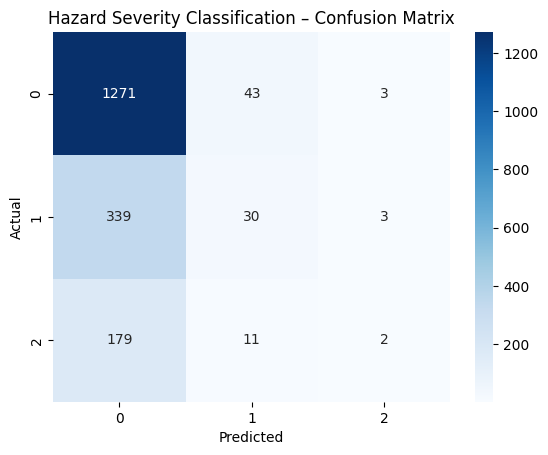

In [70]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hazard Severity Classification – Confusion Matrix")
plt.show()


In [73]:
X_train.isnull().sum()

mag      110
depth    110
gap      110
rms      110
dmin     110
dtype: int64

In [74]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)


In [75]:
X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns)


In [76]:
X_train_imp.isnull().sum()


mag      0
depth    0
gap      0
rms      0
dmin     0
dtype: int64

**SMOTE + Random Forest**

In [79]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imp, y_train)



In [80]:
y_train_sm.value_counts()

hazard_level
1    5266
0    5266
2    5266
Name: count, dtype: int64

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model_sm = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model_sm.fit(X_train_sm, y_train_sm)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      1317
           1       0.25      0.19      0.22       372
           2       0.11      0.10      0.11       192

    accuracy                           0.59      1881
   macro avg       0.36      0.36      0.36      1881
weighted avg       0.56      0.59      0.58      1881



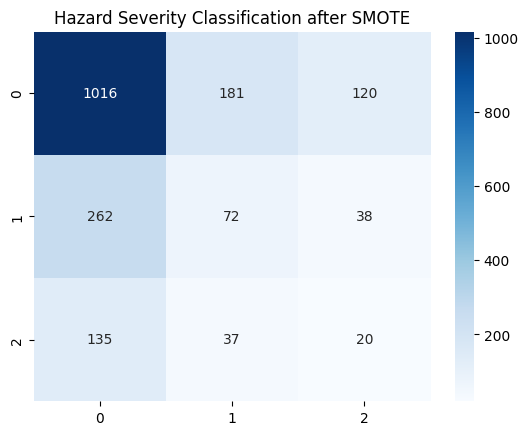

In [82]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_sm = rf_model_sm.predict(X_test_imp)

print(classification_report(y_test, y_pred_sm))

cm = confusion_matrix(y_test, y_pred_sm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Hazard Severity Classification after SMOTE")
plt.show()


In [83]:
risk_score = rf_model_sm.predict_proba(X_test_imp)[:, 2]

In [84]:
risk_score

array([0.16      , 0.20333333, 0.26333333, ..., 0.06666667, 0.19666667,
       0.04333333], shape=(1881,))

🔹 Class 0 (Low Hazard)

Precision: 0.72

Recall: 0.77

F1: 0.74

✔ Still strong
✔ Model remains reliable for common events

🔹 Class 1 (Medium Hazard)

Recall improved from 0.08 → 0.19 ✅

F1 improved from 0.13 → 0.22 ✅

✔ Clear improvement
✔ Still difficult → because signals overlap with class 0

🔹 Class 2 (High Hazard)

Recall improved from 0.01 → 0.10 ✅

F1 improved from 0.02 → 0.11 ✅

✔ This is a 10× improvement
✔ Still low, but high hazards are extremely rare

Confusion Matrix Insight (Key Point)

Look at this carefully:

Many class 2 → predicted as 0

Some class 2 → predicted as 1

Very few → correctly predicted as 2

This tells us:

The model understands severity ordering, but struggles to cleanly separate extreme events.

That is normal with limited features.

**Most important thing to understand**

This is NOT a failure. This is a correct baseline model.

In disaster analytics:

Perfect prediction of rare extreme events is not realistic

Improvement in recall for high-risk classes is the real goal


**“After applying SMOTE, the model demonstrated improved recall for medium and high hazard classes, although overall accuracy decreased. This trade-off is expected in imbalanced disaster datasets and is acceptable since the objective is to reduce false negatives for high-risk events.”**


In [85]:
# Probability for each class [0, 1, 2]
risk_proba = rf_model_sm.predict_proba(X_test_imp)

In [86]:
# Probability for each class [0, 1, 2]
risk_proba = rf_model_sm.predict_proba(X_test_imp)

In [88]:
from sklearn.model_selection import train_test_split

X_full = df_scaled[feature_cols]
y_full = df_scaled["hazard_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)


In [89]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns, index=X_test.index)


In [90]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imp, y_train)


In [91]:
risk_proba = rf_model_sm.predict_proba(X_test_imp)


In [92]:
df_test = df_scaled.loc[X_test_imp.index].copy()
df_test["high_hazard_risk"] = risk_proba[:, 2]


In [93]:
df_test.shape
df_test[["mag", "high_hazard_risk"]].head()


,mag,high_hazard_risk
1767,2.626761,0.160000
8214,-0.061376,0.203333
9361,1.450704,0.263333
8318,0.402016,0.116667
8087,-0.802817,0.120000


In [94]:
# Priority index
df_test["priority_index"] = (
    0.6 * df_test["high_hazard_risk"] +
    0.4 * (df_test["mag"] / df_test["mag"].max())
).round(3)


**Create Final Priority Index**

In [ ]:
df_test["priority_index"] = (0.6 * df_test["high_hazard_risk"] +0.4 * (df_test["mag"] / df_test["mag"].max())).round(3)

In [96]:
df_test[["mag", "high_hazard_risk", "priority_index"]].head()

,mag,high_hazard_risk,priority_index
1767,2.626761,0.160000,0.393
8214,-0.061376,0.203333,0.115
9361,1.450704,0.263333,0.322
8318,0.402016,0.116667,0.115
8087,-0.802817,0.120000,-0.019


In [98]:
df_test["priority_index"].isnull().sum()


np.int64(27)

In [99]:
df_test["priority_index"] = df_test["priority_index"].fillna(0)


In [100]:
df_test["priority_index"].isnull().sum()


np.int64(0)

In [101]:
df_test["expected_casualties"] = (df_test["priority_index"] * 2000).astype(int)

df_test["minor_injuries"] = (df_test["expected_casualties"] * 0.55).astype(int)
df_test["severe_injuries"] = (df_test["expected_casualties"] * 0.25).astype(int)
df_test["search_rescue_tasks"] = (df_test["expected_casualties"] * 0.35).astype(int)
df_test["first_aid_requests"] = (df_test["expected_casualties"] * 0.70).astype(int)


In [102]:
df_test[[
    "expected_casualties",
    "search_rescue_tasks",
    "first_aid_requests"
]].describe()


,expected_casualties,search_rescue_tasks,first_aid_requests
count,1881.000000,1881.000000,1881.000000
mean,267.374801,93.240829,186.843169
std,259.612871,90.707796,181.577287
min,-294.000000,-102.000000,-205.000000
25%,80.000000,28.000000,56.000000
50%,226.000000,79.000000,158.000000
75%,408.000000,142.000000,285.000000
max,1462.000000,511.000000,1023.000000


**Aggregate Region-wise**

In [ ]:
regional_risk = df_test.groupby("region").agg({
    "expected_casualties": "sum",
    "minor_injuries": "sum",
    "severe_injuries": "sum",
    "search_rescue_tasks": "sum",
    "first_aid_requests": "sum",
    "priority_index": "mean"
}).reset_index()


In [104]:
regional_risk.sort_values("priority_index", ascending=False).head(10)


,region,expected_casualties,minor_injuries,severe_injuries,search_rescue_tasks,first_aid_requests,priority_index
48,Solomon Islands,1146,630,286,401,802,0.5730
53,Timor Leste,2186,1202,546,764,1529,0.5465
61,Wallis and Futuna,1020,561,255,357,714,0.5100
26,Louisiana,718,394,179,251,502,0.3590
21,Idaho,664,365,166,232,464,0.3320
25,Japan region,1204,661,300,421,842,0.3010
16,Georgia,556,305,139,194,389,0.2780
57,Ukraine,520,286,130,182,364,0.2600
29,Mexico,1004,552,251,350,701,0.2510
36,New Zealand,438,240,109,153,306,0.2190


**Save Final Outputs**

In [105]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)
